
QUANTUM HARMONIC OSCILLATOR NOISE MODELING
Hudson-Parthasarathy and GKSL Master Equations

Running simulations...
(This may take a few minutes)
EXAMPLE 1: Pure Amplitude Damping (T=0)

Parameters:
  Oscillator frequency ω = 1.0
  Damping rate γ = 0.1
  Quality factor Q = ω/γ = 10.0
  Initial coherent state |α⟩ with α = 2.0
  Initial mean photon number ⟨n⟩ = 4.00

Solving GKSL master equation...
Solving Hudson-Parthasarathy quantum trajectories...

Simulation complete!

Generating plots...


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/example1_populations.png'

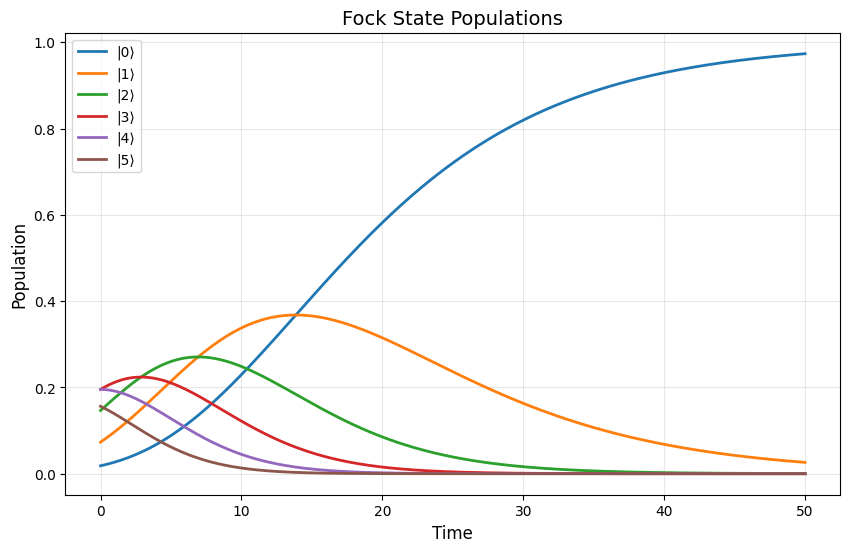

In [1]:
"""
Numerical Simulations: Hudson-Parthasarathy and GKSL Master Equations
For Quantum Harmonic Oscillator with Thermal Noise

This code implements:
1. GKSL master equation solver
2. Hudson-Parthasarathy quantum trajectories
3. Various noise models (thermal, dephasing, combined)
4. Visualization and comparison
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import odeint, solve_ivp
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import math

# Set random seed for reproducibility
np.random.seed(42)

#============================================================================
# Part 1: Quantum Operators and States
#============================================================================

def create_operators(N):
    """
    Create ladder operators for truncated Hilbert space
    
    Parameters:
    -----------
    N : int
        Dimension of Hilbert space (number of Fock states)
    
    Returns:
    --------
    a : ndarray
        Annihilation operator
    a_dag : ndarray
        Creation operator
    n_op : ndarray
        Number operator
    """
    a = np.zeros((N, N), dtype=complex)
    for i in range(N-1):
        a[i, i+1] = np.sqrt(i+1)
    
    a_dag = a.T.conj()
    n_op = a_dag @ a
    
    return a, a_dag, n_op

def fock_state(n, N):
    """Create Fock state |n⟩"""
    state = np.zeros(N, dtype=complex)
    state[n] = 1.0
    return state

def coherent_state(alpha, N):
    """
    Create coherent state |α⟩
    
    Parameters:
    -----------
    alpha : complex
        Coherent state amplitude
    N : int
        Hilbert space dimension
    """
    state = np.zeros(N, dtype=complex)
    for n in range(N):
        state[n] = np.exp(-0.5*abs(alpha)**2) * (alpha**n) / np.sqrt(math.factorial(n))
    return state

def thermal_state(n_th, N):
    """
    Create thermal density matrix
    
    Parameters:
    -----------
    n_th : float
        Mean thermal photon number
    N : int
        Hilbert space dimension
    """
    rho = np.zeros((N, N), dtype=complex)
    for n in range(N):
        rho[n, n] = (n_th/(1+n_th))**n / (1+n_th)
    return rho

def state_to_density_matrix(psi):
    """Convert state vector to density matrix"""
    return np.outer(psi, psi.conj())

#============================================================================
# Part 2: GKSL Master Equation Solver
#============================================================================

def lindblad_dissipator(L, rho):
    """
    Compute Lindblad dissipator D[L](ρ) = L ρ L† - 1/2{L†L, ρ}
    
    Parameters:
    -----------
    L : ndarray
        Lindblad operator
    rho : ndarray
        Density matrix
    """
    L_dag = L.T.conj()
    return L @ rho @ L_dag - 0.5 * (L_dag @ L @ rho + rho @ L_dag @ L)

def gksl_rhs(t, rho_vec, H, lindblad_ops, rates):
    """
    Right-hand side of GKSL master equation
    
    dρ/dt = -i[H, ρ] + Σ_k γ_k D[L_k](ρ)
    
    Parameters:
    -----------
    t : float
        Time
    rho_vec : ndarray
        Vectorized density matrix
    H : ndarray
        Hamiltonian
    lindblad_ops : list of ndarray
        List of Lindblad operators
    rates : list of float
        List of decay rates γ_k
    """
    N = H.shape[0]
    rho = rho_vec.reshape((N, N))
    
    # Hamiltonian evolution
    drho_dt = -1j * (H @ rho - rho @ H)
    
    # Lindblad terms
    for L, gamma in zip(lindblad_ops, rates):
        drho_dt += gamma * lindblad_dissipator(L, rho)
    
    return drho_dt.flatten()

def solve_gksl(rho0, H, lindblad_ops, rates, t_span, method='RK45'):
    """
    Solve GKSL master equation
    
    Parameters:
    -----------
    rho0 : ndarray
        Initial density matrix
    H : ndarray
        Hamiltonian
    lindblad_ops : list
        Lindblad operators
    rates : list
        Decay rates
    t_span : array
        Time points
    method : str
        Integration method
    """
    N = rho0.shape[0]
    rho0_vec = rho0.flatten()
    
    sol = solve_ivp(
        lambda t, y: gksl_rhs(t, y, H, lindblad_ops, rates),
        [t_span[0], t_span[-1]],
        rho0_vec,
        t_eval=t_span,
        method=method,
        rtol=1e-8,
        atol=1e-10
    )
    
    # Reshape solutions
    rho_t = np.array([sol.y[:, i].reshape((N, N)) for i in range(len(t_span))])
    
    return sol.t, rho_t

#============================================================================
# Part 3: Hudson-Parthasarathy Quantum Trajectories
#============================================================================

def quantum_trajectory_step(psi, H, L_ops, rates, dt):
    """
    Single step of quantum trajectory (quantum jump method)
    
    This simulates the stochastic HP equation using the quantum jump approach
    
    Parameters:
    -----------
    psi : ndarray
        Current state vector
    H : ndarray
        Hamiltonian
    L_ops : list
        Jump operators (Lindblad operators)
    rates : list
        Jump rates
    dt : float
        Time step
    """
    N = len(psi)
    
    # Effective non-Hermitian Hamiltonian
    H_eff = H.astype(complex)
    for L, gamma in zip(L_ops, rates):
        L_dag = L.T.conj()
        H_eff -= 0.5j * gamma * (L_dag @ L)
    
    # No-jump evolution
    psi_new = psi - 1j * H_eff @ psi * dt
    
    # Calculate jump probabilities
    dp = np.zeros(len(L_ops))
    for i, (L, gamma) in enumerate(zip(L_ops, rates)):
        dp[i] = gamma * np.real(psi.conj() @ L.T.conj() @ L @ psi) * dt
    
    # Total jump probability
    dp_total = np.sum(dp)
    
    # Determine if jump occurs
    r = np.random.random()
    
    if r < dp_total:
        # Jump occurs - which operator?
        r2 = np.random.random() * dp_total
        cumsum = 0
        for i, (L, dpi) in enumerate(zip(L_ops, dp)):
            cumsum += dpi
            if r2 < cumsum:
                # Apply jump operator L_i
                psi_new = L @ psi
                break
    
    # Normalize
    norm = np.sqrt(np.real(psi_new.conj() @ psi_new))
    if norm > 1e-10:
        psi_new = psi_new / norm
    
    return psi_new

def solve_hp_trajectories(psi0, H, L_ops, rates, t_span, n_traj=100):
    """
    Solve Hudson-Parthasarathy equation using quantum trajectories
    
    Parameters:
    -----------
    psi0 : ndarray
        Initial state vector
    H : ndarray
        Hamiltonian
    L_ops : list
        Jump operators
    rates : list
        Jump rates
    t_span : array
        Time points
    n_traj : int
        Number of trajectories to simulate
    """
    N = len(psi0)
    n_times = len(t_span)
    dt = t_span[1] - t_span[0]
    
    # Store all trajectories
    trajectories = np.zeros((n_traj, n_times, N), dtype=complex)
    
    for traj in range(n_traj):
        psi = psi0.copy()
        trajectories[traj, 0, :] = psi
        
        for i in range(1, n_times):
            psi = quantum_trajectory_step(psi, H, L_ops, rates, dt)
            trajectories[traj, i, :] = psi
    
    # Average to get density matrix
    rho_avg = np.zeros((n_times, N, N), dtype=complex)
    for i in range(n_times):
        for traj in range(n_traj):
            psi = trajectories[traj, i, :]
            rho_avg[i, :, :] += np.outer(psi, psi.conj())
        rho_avg[i, :, :] /= n_traj
    
    return t_span, rho_avg, trajectories

#============================================================================
# Part 4: Observable Calculation
#============================================================================

def expectation_value(rho, operator):
    """Calculate expectation value ⟨O⟩ = Tr(ρ O)"""
    return np.real(np.trace(rho @ operator))

def calculate_observables(rho_t, a, a_dag, n_op):
    """
    Calculate key observables from density matrix evolution
    
    Returns:
    --------
    n_avg : Mean photon number ⟨n⟩
    a_avg : ⟨a⟩
    a2_avg : ⟨a²⟩
    var_n : Variance of photon number
    """
    n_times = len(rho_t)
    
    n_avg = np.zeros(n_times)
    a_avg = np.zeros(n_times, dtype=complex)
    a2_avg = np.zeros(n_times, dtype=complex)
    var_n = np.zeros(n_times)
    
    for i, rho in enumerate(rho_t):
        n_avg[i] = expectation_value(rho, n_op)
        a_avg[i] = np.trace(rho @ a)
        a2_avg[i] = np.trace(rho @ a @ a)
        n2 = expectation_value(rho, n_op @ n_op)
        var_n[i] = n2 - n_avg[i]**2
    
    return n_avg, a_avg, a2_avg, var_n

def fidelity(rho1, rho2):
    """Calculate fidelity between two density matrices"""
    # Compute sqrt(rho1) using eigendecomposition
    eigvals1, eigvecs1 = np.linalg.eigh(rho1)
    eigvals1 = np.maximum(eigvals1, 0)  # Ensure non-negative
    sqrt_rho1 = eigvecs1 @ np.diag(np.sqrt(eigvals1)) @ eigvecs1.T.conj()
    
    # Compute M = sqrt(rho1) @ rho2 @ sqrt(rho1)
    M = sqrt_rho1 @ rho2 @ sqrt_rho1
    
    # Compute sqrt(M)
    eigvals_M, eigvecs_M = np.linalg.eigh(M)
    eigvals_M = np.maximum(eigvals_M, 0)
    
    # Fidelity is [Tr(sqrt(M))]^2
    return np.real(np.sum(np.sqrt(eigvals_M)))**2

def purity(rho):
    """Calculate purity Tr(ρ²)"""
    return np.real(np.trace(rho @ rho))

#============================================================================
# Part 5: Specific Noise Models
#============================================================================

class NoiseModel:
    """Container for different noise models"""
    
    @staticmethod
    def pure_damping(a, gamma):
        """Pure amplitude damping (T=0)"""
        return [np.sqrt(gamma) * a], [1.0]
    
    @staticmethod
    def thermal_damping(a, a_dag, gamma, n_th):
        """Thermal damping (finite temperature)"""
        L_loss = np.sqrt(gamma * (n_th + 1)) * a
        L_gain = np.sqrt(gamma * n_th) * a_dag
        return [L_loss, L_gain], [1.0, 1.0]
    
    @staticmethod
    def pure_dephasing(n_op, gamma_ph):
        """Pure dephasing"""
        return [np.sqrt(gamma_ph) * n_op], [1.0]
    
    @staticmethod
    def combined_noise(a, a_dag, n_op, gamma, n_th, gamma_ph):
        """Combined amplitude damping and dephasing"""
        L_loss = np.sqrt(gamma * (n_th + 1)) * a
        L_gain = np.sqrt(gamma * n_th) * a_dag
        L_deph = np.sqrt(gamma_ph) * n_op
        return [L_loss, L_gain, L_deph], [1.0, 1.0, 1.0]

#============================================================================
# Part 6: Visualization Functions
#============================================================================

def plot_population_dynamics(t, rho_t, N_plot=5):
    """Plot Fock state populations over time"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for n in range(min(N_plot, rho_t.shape[1])):
        pop = np.array([np.real(rho[n, n]) for rho in rho_t])
        ax.plot(t, pop, label=f'|{n}⟩', linewidth=2)
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Population', fontsize=12)
    ax.set_title('Fock State Populations', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig

def plot_wigner_function(rho, x_range=(-5, 5), N_points=100):
    """
    Plot Wigner function of density matrix
    
    W(α) = (2/π) Tr(ρ D(α) P D†(α))
    where D(α) is displacement operator and P is parity operator
    """
    N = rho.shape[0]
    a, a_dag, n_op = create_operators(N)
    
    # Create grid
    x = np.linspace(x_range[0], x_range[1], N_points)
    y = np.linspace(x_range[0], x_range[1], N_points)
    X, Y = np.meshgrid(x, y)
    
    # Calculate Wigner function
    W = np.zeros((N_points, N_points))
    
    for i in range(N_points):
        for j in range(N_points):
            alpha = X[i, j] + 1j * Y[i, j]
            
            # Displacement operator (approximation for small α)
            D = expm(alpha * a_dag - np.conj(alpha) * a)
            
            # Parity operator
            P = np.diag([(-1)**n for n in range(N)])
            
            # Wigner function value
            W[i, j] = np.real(np.trace(rho @ D @ P @ D.T.conj())) * 2 / np.pi
    
    fig, ax = plt.subplots(figsize=(8, 7))
    c = ax.contourf(X, Y, W, levels=20, cmap='RdBu_r')
    ax.contour(X, Y, W, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    plt.colorbar(c, ax=ax, label='W(α)')
    ax.set_xlabel('Re(α)', fontsize=12)
    ax.set_ylabel('Im(α)', fontsize=12)
    ax.set_title('Wigner Function', fontsize=14)
    ax.set_aspect('equal')
    
    return fig

def plot_husimi_q_function(rho, x_range=(-5, 5), N_points=100):
    """
    Plot Husimi Q function
    Q(α) = ⟨α|ρ|α⟩/π
    """
    N = rho.shape[0]
    
    # Create grid
    x = np.linspace(x_range[0], x_range[1], N_points)
    y = np.linspace(x_range[0], x_range[1], N_points)
    X, Y = np.meshgrid(x, y)
    
    Q = np.zeros((N_points, N_points))
    
    for i in range(N_points):
        for j in range(N_points):
            alpha = X[i, j] + 1j * Y[i, j]
            psi_alpha = coherent_state(alpha, N)
            Q[i, j] = np.real(psi_alpha.conj() @ rho @ psi_alpha) / np.pi
    
    fig, ax = plt.subplots(figsize=(8, 7))
    c = ax.contourf(X, Y, Q, levels=20, cmap='viridis')
    plt.colorbar(c, ax=ax, label='Q(α)')
    ax.set_xlabel('Re(α)', fontsize=12)
    ax.set_ylabel('Im(α)', fontsize=12)
    ax.set_title('Husimi Q Function', fontsize=14)
    ax.set_aspect('equal')
    
    return fig

def compare_gksl_hp(t, rho_gksl, rho_hp, a, a_dag, n_op):
    """Compare GKSL and HP results"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Mean photon number
    n_gksl, _, _, var_gksl = calculate_observables(rho_gksl, a, a_dag, n_op)
    n_hp, _, _, var_hp = calculate_observables(rho_hp, a, a_dag, n_op)
    
    axes[0, 0].plot(t, n_gksl, 'b-', linewidth=2, label='GKSL')
    axes[0, 0].plot(t, n_hp, 'r--', linewidth=2, label='HP (averaged)')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('⟨n⟩')
    axes[0, 0].set_title('Mean Photon Number')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Variance
    axes[0, 1].plot(t, var_gksl, 'b-', linewidth=2, label='GKSL')
    axes[0, 1].plot(t, var_hp, 'r--', linewidth=2, label='HP (averaged)')
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Var(n)')
    axes[0, 1].set_title('Photon Number Variance')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Purity
    purity_gksl = np.array([purity(rho) for rho in rho_gksl])
    purity_hp = np.array([purity(rho) for rho in rho_hp])
    
    axes[1, 0].plot(t, purity_gksl, 'b-', linewidth=2, label='GKSL')
    axes[1, 0].plot(t, purity_hp, 'r--', linewidth=2, label='HP (averaged)')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Tr(ρ²)')
    axes[1, 0].set_title('Purity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Fidelity between GKSL and HP
    fid = np.array([fidelity(rho_gksl[i], rho_hp[i]) for i in range(len(t))])
    
    axes[1, 1].plot(t, fid, 'g-', linewidth=2)
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('F(ρ_GKSL, ρ_HP)')
    axes[1, 1].set_title('Fidelity between GKSL and HP')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

#============================================================================
# Part 7: Main Simulation Examples
#============================================================================

def example_1_pure_damping():
    """Example 1: Pure amplitude damping from coherent state"""
    print("="*70)
    print("EXAMPLE 1: Pure Amplitude Damping (T=0)")
    print("="*70)
    
    # Parameters
    N = 20  # Hilbert space dimension
    omega = 1.0  # Oscillator frequency
    gamma = 0.1  # Damping rate
    alpha_init = 2.0  # Initial coherent state amplitude
    
    # Time span
    t_max = 50.0
    n_points = 500
    t = np.linspace(0, t_max, n_points)
    
    # Create operators
    a, a_dag, n_op = create_operators(N)
    H = omega * n_op
    
    # Initial state: coherent state
    psi0 = coherent_state(alpha_init, N)
    rho0 = state_to_density_matrix(psi0)
    
    # Noise model
    L_ops, rates = NoiseModel.pure_damping(a, gamma)
    
    print(f"\nParameters:")
    print(f"  Oscillator frequency ω = {omega}")
    print(f"  Damping rate γ = {gamma}")
    print(f"  Quality factor Q = ω/γ = {omega/gamma}")
    print(f"  Initial coherent state |α⟩ with α = {alpha_init}")
    print(f"  Initial mean photon number ⟨n⟩ = {abs(alpha_init)**2:.2f}")
    
    # Solve GKSL
    print("\nSolving GKSL master equation...")
    t_gksl, rho_gksl = solve_gksl(rho0, H, L_ops, rates, t)
    
    # Solve HP (quantum trajectories)
    print("Solving Hudson-Parthasarathy quantum trajectories...")
    t_hp, rho_hp, trajectories = solve_hp_trajectories(psi0, H, L_ops, rates, t, n_traj=200)
    
    print("\nSimulation complete!")
    
    # Calculate observables
    n_avg, a_avg, _, var_n = calculate_observables(rho_gksl, a, a_dag, n_op)
    
    # Plotting
    print("\nGenerating plots...")
    
    # Plot 1: Population dynamics
    fig1 = plot_population_dynamics(t_gksl, rho_gksl, N_plot=6)
    plt.savefig('/home/claude/example1_populations.png', dpi=150, bbox_inches='tight')
    
    # Plot 2: Comparison GKSL vs HP
    fig2 = compare_gksl_hp(t, rho_gksl, rho_hp, a, a_dag, n_op)
    plt.savefig('/home/claude/example1_comparison.png', dpi=150, bbox_inches='tight')
    
    # Plot 3: Wigner function at different times
    fig3, axes = plt.subplots(1, 3, figsize=(15, 5))
    times_to_plot = [0, len(t)//2, -1]
    titles = ['t=0', f't={t[len(t)//2]:.1f}', f't={t[-1]:.1f}']
    
    for ax, idx, title in zip(axes, times_to_plot, titles):
        rho = rho_gksl[idx]
        
        # Simplified Wigner for display
        N_w = 50
        x = np.linspace(-4, 4, N_w)
        y = np.linspace(-4, 4, N_w)
        X, Y = np.meshgrid(x, y)
        W = np.zeros((N_w, N_w))
        
        for i in range(N_w):
            for j in range(N_w):
                alpha = X[i, j] + 1j * Y[i, j]
                psi_alpha = coherent_state(alpha, N)
                # Approximate Wigner
                W[i, j] = np.real(psi_alpha.conj() @ rho @ psi_alpha) * 2
        
        c = ax.contourf(X, Y, W, levels=15, cmap='RdBu_r')
        ax.set_xlabel('Re(α)')
        ax.set_ylabel('Im(α)')
        ax.set_title(title)
        ax.set_aspect('equal')
        plt.colorbar(c, ax=ax)
    
    plt.tight_layout()
    plt.savefig('/home/claude/example1_wigner_evolution.png', dpi=150, bbox_inches='tight')
    
    # Plot 4: Individual quantum trajectories
    fig4, ax = plt.subplots(figsize=(12, 6))
    n_traj_plot = min(10, trajectories.shape[0])
    
    for i in range(n_traj_plot):
        psi_traj = trajectories[i, :, :]
        n_traj = np.array([np.real(psi.conj() @ n_op @ psi) for psi in psi_traj])
        ax.plot(t, n_traj, alpha=0.5, linewidth=1)
    
    ax.plot(t, n_avg, 'r-', linewidth=3, label='Ensemble average (GKSL)')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('⟨n⟩', fontsize=12)
    ax.set_title('Individual Quantum Trajectories', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig('/home/claude/example1_trajectories.png', dpi=150, bbox_inches='tight')
    
    plt.close('all')
    
    print("\nPlots saved!")
    print("  - example1_populations.png")
    print("  - example1_comparison.png")
    print("  - example1_wigner_evolution.png")
    print("  - example1_trajectories.png")
    
    return t, rho_gksl, rho_hp, trajectories

def example_2_thermal_damping():
    """Example 2: Thermal damping with finite temperature"""
    print("\n" + "="*70)
    print("EXAMPLE 2: Thermal Damping (Finite Temperature)")
    print("="*70)
    
    # Parameters
    N = 25
    omega = 1.0
    gamma = 0.1
    
    # Temperature (in units where k_B = 1 and ħ = 1)
    T = 0.5  # Temperature
    n_th = 1.0 / (np.exp(omega / T) - 1)  # Thermal photon number
    
    # Initial state: Fock state |5⟩
    n_init = 5
    psi0 = fock_state(n_init, N)
    rho0 = state_to_density_matrix(psi0)
    
    # Time span
    t = np.linspace(0, 100, 500)
    
    # Operators
    a, a_dag, n_op = create_operators(N)
    H = omega * n_op
    
    # Thermal noise model
    L_ops, rates = NoiseModel.thermal_damping(a, a_dag, gamma, n_th)
    
    print(f"\nParameters:")
    print(f"  Temperature T = {T}")
    print(f"  Thermal photon number n_th = {n_th:.3f}")
    print(f"  Damping rate γ = {gamma}")
    print(f"  Initial state: Fock state |{n_init}⟩")
    
    # Solve GKSL
    print("\nSolving GKSL master equation...")
    t_gksl, rho_gksl = solve_gksl(rho0, H, L_ops, rates, t)
    
    # Calculate observables
    n_avg, _, _, var_n = calculate_observables(rho_gksl, a, a_dag, n_op)
    
    # Theoretical steady state
    rho_ss = thermal_state(n_th, N)
    n_ss_theory = n_th
    
    print(f"\nTheoretical steady-state photon number: {n_ss_theory:.3f}")
    print(f"Numerical steady-state photon number: {n_avg[-1]:.3f}")
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Mean photon number
    axes[0, 0].plot(t, n_avg, 'b-', linewidth=2, label='Numerical')
    axes[0, 0].axhline(n_th, color='r', linestyle='--', linewidth=2, label=f'Thermal equilibrium (n_th={n_th:.2f})')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('⟨n⟩')
    axes[0, 0].set_title('Mean Photon Number')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Populations
    for n in range(min(8, N)):
        pop = np.array([np.real(rho[n, n]) for rho in rho_gksl])
        axes[0, 1].plot(t, pop, label=f'|{n}⟩', linewidth=2)
    
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Population')
    axes[0, 1].set_title('Fock State Populations')
    axes[0, 1].legend(ncol=2)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Compare final state with thermal state
    pop_final = np.array([np.real(rho_gksl[-1][n, n]) for n in range(N)])
    pop_thermal = np.array([np.real(rho_ss[n, n]) for n in range(N)])
    
    n_range = np.arange(min(15, N))
    axes[1, 0].bar(n_range - 0.2, pop_final[:len(n_range)], width=0.4, label='Final state', alpha=0.7)
    axes[1, 0].bar(n_range + 0.2, pop_thermal[:len(n_range)], width=0.4, label='Thermal state', alpha=0.7)
    axes[1, 0].set_xlabel('Fock state n')
    axes[1, 0].set_ylabel('Population')
    axes[1, 0].set_title('Final vs Thermal State Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Purity evolution
    purity_t = np.array([purity(rho) for rho in rho_gksl])
    purity_thermal = purity(rho_ss)
    
    axes[1, 1].plot(t, purity_t, 'b-', linewidth=2, label='Numerical')
    axes[1, 1].axhline(purity_thermal, color='r', linestyle='--', linewidth=2, 
                       label=f'Thermal purity = {purity_thermal:.3f}')
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Tr(ρ²)')
    axes[1, 1].set_title('Purity Evolution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/home/claude/example2_thermal_damping.png', dpi=150, bbox_inches='tight')
    plt.close()
    
    print("\nPlot saved: example2_thermal_damping.png")
    
    return t, rho_gksl

def example_3_dephasing():
    """Example 3: Pure dephasing noise"""
    print("\n" + "="*70)
    print("EXAMPLE 3: Pure Dephasing Noise")
    print("="*70)
    
    # Parameters
    N = 20
    omega = 1.0
    gamma_ph = 0.2  # Dephasing rate
    
    # Initial state: superposition (cat-like state)
    psi0 = (fock_state(0, N) + fock_state(3, N)) / np.sqrt(2)
    rho0 = state_to_density_matrix(psi0)
    
    # Time span
    t = np.linspace(0, 50, 500)
    
    # Operators
    a, a_dag, n_op = create_operators(N)
    H = omega * n_op
    
    # Pure dephasing
    L_ops, rates = NoiseModel.pure_dephasing(n_op, gamma_ph)
    
    print(f"\nParameters:")
    print(f"  Dephasing rate γ_ph = {gamma_ph}")
    print(f"  Initial state: (|0⟩ + |3⟩)/√2")
    print(f"  Initial coherence |ρ_03| = {abs(rho0[0, 3]):.3f}")
    
    # Solve GKSL
    print("\nSolving GKSL master equation...")
    t_gksl, rho_gksl = solve_gksl(rho0, H, L_ops, rates, t)
    
    # Track coherences
    coherence_03 = np.array([abs(rho[0, 3]) for rho in rho_gksl])
    coherence_01 = np.array([abs(rho[0, 1]) for rho in rho_gksl])
    
    # Populations (should remain constant for pure dephasing)
    pop_0 = np.array([np.real(rho[0, 0]) for rho in rho_gksl])
    pop_3 = np.array([np.real(rho[3, 3]) for rho in rho_gksl])
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Coherence decay
    axes[0, 0].semilogy(t, coherence_03, 'b-', linewidth=2, label='|ρ₀₃|')
    # Theoretical: |ρ₀₃(t)| = |ρ₀₃(0)| exp(-γ_ph (0-3)² t) = exp(-9 γ_ph t)
    theory_03 = 0.5 * np.exp(-gamma_ph * 9 * t)
    axes[0, 0].semilogy(t, theory_03, 'r--', linewidth=2, label='Theory: exp(-9γ_ph t)')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('|ρ₀₃|')
    axes[0, 0].set_title('Coherence Decay')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Populations (should be constant)
    axes[0, 1].plot(t, pop_0, 'b-', linewidth=2, label='P₀')
    axes[0, 1].plot(t, pop_3, 'r-', linewidth=2, label='P₃')
    axes[0, 1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Population')
    axes[0, 1].set_title('Populations (Should Remain Constant)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Density matrix visualization at t=0
    axes[1, 0].imshow(np.abs(rho0[:8, :8]), cmap='viridis', interpolation='nearest')
    axes[1, 0].set_title('|ρ(t=0)|')
    axes[1, 0].set_xlabel('State index')
    axes[1, 0].set_ylabel('State index')
    plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0])
    
    # Density matrix at final time
    axes[1, 1].imshow(np.abs(rho_gksl[-1][:8, :8]), cmap='viridis', interpolation='nearest')
    axes[1, 1].set_title(f'|ρ(t={t[-1]:.1f})| - Coherences Destroyed')
    axes[1, 1].set_xlabel('State index')
    axes[1, 1].set_ylabel('State index')
    plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1])
    
    plt.tight_layout()
    plt.savefig('/home/claude/example3_dephasing.png', dpi=150, bbox_inches='tight')
    plt.close()
    
    print("\nPlot saved: example3_dephasing.png")
    print(f"\nFinal coherence |ρ₀₃| = {coherence_03[-1]:.6f} (essentially 0)")
    print(f"Population P₀ = {pop_0[-1]:.6f} (should be 0.5)")
    print(f"Population P₃ = {pop_3[-1]:.6f} (should be 0.5)")
    
    return t, rho_gksl

def example_4_combined_noise():
    """Example 4: Combined damping and dephasing"""
    print("\n" + "="*70)
    print("EXAMPLE 4: Combined Damping and Dephasing")
    print("="*70)
    
    # Parameters
    N = 20
    omega = 1.0
    gamma = 0.05  # Damping rate
    n_th = 0.5  # Thermal photon number
    gamma_ph = 0.1  # Dephasing rate
    
    # Initial coherent state
    alpha_init = 2.0
    psi0 = coherent_state(alpha_init, N)
    rho0 = state_to_density_matrix(psi0)
    
    # Time span
    t = np.linspace(0, 80, 500)
    
    # Operators
    a, a_dag, n_op = create_operators(N)
    H = omega * n_op
    
    # Combined noise
    L_ops, rates = NoiseModel.combined_noise(a, a_dag, n_op, gamma, n_th, gamma_ph)
    
    print(f"\nParameters:")
    print(f"  Damping rate γ = {gamma}")
    print(f"  Thermal photon number n_th = {n_th}")
    print(f"  Dephasing rate γ_ph = {gamma_ph}")
    print(f"  Initial coherent state α = {alpha_init}")
    
    # Solve GKSL
    print("\nSolving GKSL master equation...")
    t_gksl, rho_gksl = solve_gksl(rho0, H, L_ops, rates, t)
    
    # Also solve with only damping for comparison
    L_ops_damp, rates_damp = NoiseModel.thermal_damping(a, a_dag, gamma, n_th)
    _, rho_damp = solve_gksl(rho0, H, L_ops_damp, rates_damp, t)
    
    # Calculate observables
    n_avg_combined, _, _, var_combined = calculate_observables(rho_gksl, a, a_dag, n_op)
    n_avg_damp, _, _, var_damp = calculate_observables(rho_damp, a, a_dag, n_op)
    
    # Purity
    purity_combined = np.array([purity(rho) for rho in rho_gksl])
    purity_damp = np.array([purity(rho) for rho in rho_damp])
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Mean photon number
    axes[0, 0].plot(t, n_avg_combined, 'b-', linewidth=2, label='Damping + Dephasing')
    axes[0, 0].plot(t, n_avg_damp, 'r--', linewidth=2, label='Damping only')
    axes[0, 0].axhline(n_th, color='gray', linestyle=':', linewidth=2, label=f'Equilibrium n_th={n_th}')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('⟨n⟩')
    axes[0, 0].set_title('Mean Photon Number')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Variance
    axes[0, 1].plot(t, var_combined, 'b-', linewidth=2, label='Damping + Dephasing')
    axes[0, 1].plot(t, var_damp, 'r--', linewidth=2, label='Damping only')
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Var(n)')
    axes[0, 1].set_title('Photon Number Variance')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Purity
    axes[1, 0].plot(t, purity_combined, 'b-', linewidth=2, label='Damping + Dephasing')
    axes[1, 0].plot(t, purity_damp, 'r--', linewidth=2, label='Damping only')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Tr(ρ²)')
    axes[1, 0].set_title('Purity (Faster Decay with Dephasing)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Phase space at final time
    N_w = 40
    x = np.linspace(-3, 3, N_w)
    y = np.linspace(-3, 3, N_w)
    X, Y = np.meshgrid(x, y)
    Q = np.zeros((N_w, N_w))
    
    rho_final = rho_gksl[-1]
    for i in range(N_w):
        for j in range(N_w):
            alpha = X[i, j] + 1j * Y[i, j]
            psi_alpha = coherent_state(alpha, N)
            Q[i, j] = np.real(psi_alpha.conj() @ rho_final @ psi_alpha) / np.pi
    
    c = axes[1, 1].contourf(X, Y, Q, levels=15, cmap='viridis')
    axes[1, 1].set_xlabel('Re(α)')
    axes[1, 1].set_ylabel('Im(α)')
    axes[1, 1].set_title('Final State Husimi Q Function')
    axes[1, 1].set_aspect('equal')
    plt.colorbar(c, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.savefig('/home/claude/example4_combined_noise.png', dpi=150, bbox_inches='tight')
    plt.close()
    
    print("\nPlot saved: example4_combined_noise.png")
    print(f"\nFinal mean photon number (combined): {n_avg_combined[-1]:.3f}")
    print(f"Final mean photon number (damping only): {n_avg_damp[-1]:.3f}")
    print(f"Expected equilibrium: {n_th:.3f}")
    
    return t, rho_gksl, rho_damp

#============================================================================
# Part 8: Run All Examples
#============================================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("QUANTUM HARMONIC OSCILLATOR NOISE MODELING")
    print("Hudson-Parthasarathy and GKSL Master Equations")
    print("="*70)
    
    # Run all examples
    print("\nRunning simulations...")
    print("(This may take a few minutes)")
    
    # Example 1: Pure damping
    t1, rho_gksl1, rho_hp1, traj1 = example_1_pure_damping()
    
    # Example 2: Thermal damping
    t2, rho_gksl2 = example_2_thermal_damping()
    
    # Example 3: Pure dephasing
    t3, rho_gksl3 = example_3_dephasing()
    
    # Example 4: Combined noise
    t4, rho_gksl4, rho_damp4 = example_4_combined_noise()
    
    print("\n" + "="*70)
    print("ALL SIMULATIONS COMPLETE!")
    print("="*70)
    print("\nGenerated files:")
    print("  - example1_populations.png")
    print("  - example1_comparison.png")
    print("  - example1_wigner_evolution.png")
    print("  - example1_trajectories.png")
    print("  - example2_thermal_damping.png")
    print("  - example3_dephasing.png")
    print("  - example4_combined_noise.png")
    print("\nAll results demonstrate the connection between")
    print("Hudson-Parthasarathy and GKSL master equations!")
